In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

from collections import Counter
from wordcloud import WordCloud

import nltk
from nltk.corpus import stopwords


nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [230]:
fake = pd.read_csv('fake.csv')

In [231]:
fake

,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"
...,...,...,...,...
23476,McPain: John McCain Furious That Iran Treated ...,21st Century Wire says As 21WIRE reported earl...,Middle-east,"January 16, 2016"
23477,JUSTICE? Yahoo Settles E-mail Privacy Class-ac...,21st Century Wire says It s a familiar theme. ...,Middle-east,"January 16, 2016"
23478,Sunnistan: US and Allied ‘Safe Zone’ Plan to T...,Patrick Henningsen 21st Century WireRemember ...,Middle-east,"January 15, 2016"
23479,How to Blow $700 Million: Al Jazeera America F...,21st Century Wire says Al Jazeera America will...,Middle-east,"January 14, 2016"


In [232]:
fake.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23481 entries, 0 to 23480
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    23481 non-null  object
 1   text     23481 non-null  object
 2   subject  23481 non-null  object
 3   date     23481 non-null  object
dtypes: object(4)
memory usage: 733.9+ KB


In [233]:
true = pd.read_csv('true.csv')

In [234]:
true

,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"
...,...,...,...,...
21412,'Fully committed' NATO backs new U.S. approach...,BRUSSELS (Reuters) - NATO allies on Tuesday we...,worldnews,"August 22, 2017"
21413,LexisNexis withdrew two products from Chinese ...,"LONDON (Reuters) - LexisNexis, a provider of l...",worldnews,"August 22, 2017"
21414,Minsk cultural hub becomes haven from authorities,MINSK (Reuters) - In the shadow of disused Sov...,worldnews,"August 22, 2017"
21415,Vatican upbeat on possibility of Pope Francis ...,MOSCOW (Reuters) - Vatican Secretary of State ...,worldnews,"August 22, 2017"


In [235]:
true.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21417 entries, 0 to 21416
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    21417 non-null  object
 1   text     21417 non-null  object
 2   subject  21417 non-null  object
 3   date     21417 non-null  object
dtypes: object(4)
memory usage: 669.4+ KB


In [236]:
fake["label"] = 0
true["label"] = 1

#merge files
df = pd.concat([fake, true], axis=0)

#shuffle rows
df = df.sample(frac=1, random_state=42)

df = df.reset_index(drop=True)

#new dataset
df.to_csv("news_dataset.csv", index=False)

In [237]:
df

,title,text,subject,date,label
0,Ben Stein Calls Out 9th Circuit Court: Committ...,"21st Century Wire says Ben Stein, reputable pr...",US_News,"February 13, 2017",0
1,Trump drops Steve Bannon from National Securit...,WASHINGTON (Reuters) - U.S. President Donald T...,politicsNews,"April 5, 2017",1
2,Puerto Rico expects U.S. to lift Jones Act shi...,(Reuters) - Puerto Rico Governor Ricardo Rosse...,politicsNews,"September 27, 2017",1
3,OOPS: Trump Just Accidentally Confirmed He Le...,"On Monday, Donald Trump once again embarrassed...",News,"May 22, 2017",0
4,Donald Trump heads for Scotland to reopen a go...,"GLASGOW, Scotland (Reuters) - Most U.S. presid...",politicsNews,"June 24, 2016",1
...,...,...,...,...,...
44893,UNREAL! CBS’S TED KOPPEL Tells Sean Hannity He...,,politics,"Mar 27, 2017",0
44894,PM May seeks to ease Japan's Brexit fears duri...,LONDON/TOKYO (Reuters) - British Prime Ministe...,worldnews,"August 29, 2017",1
44895,Merkel: Difficult German coalition talks can r...,BERLIN (Reuters) - Chancellor Angela Merkel sa...,worldnews,"November 16, 2017",1
44896,Trump Stole An Idea From North Korean Propaga...,Jesus f*cking Christ our President* is a moron...,News,"July 14, 2017",0


In [238]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44898 entries, 0 to 44897
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    44898 non-null  object
 1   text     44898 non-null  object
 2   subject  44898 non-null  object
 3   date     44898 non-null  object
 4   label    44898 non-null  int64 
dtypes: int64(1), object(4)
memory usage: 1.7+ MB


In [239]:
df.drop_duplicates(inplace=True)

print(f"Dataset shape after removing duplicates: {df.shape}")

Dataset shape after removing duplicates: (44689, 5)


In [240]:
df.isnull().sum()

title      0
text       0
subject    0
date       0
label      0
dtype: int64

In [241]:
df.shape

(44689, 5)

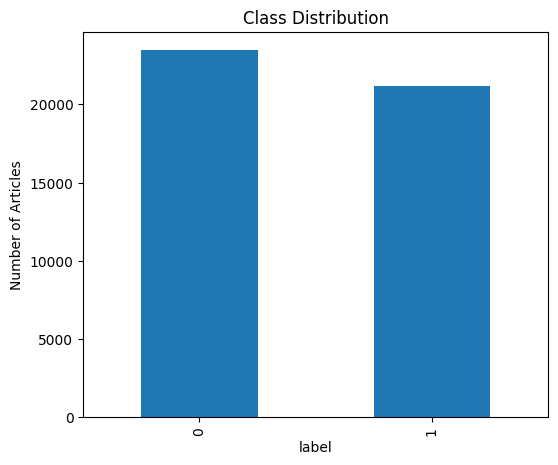


Class Distribution
label
0    23478
1    21211
Name: count, dtype: int64


In [242]:
# ============================================================
# CLASS DISTRIBUTION
# ============================================================

plt.figure(figsize=(6,5))

df["label"].value_counts().plot(
    kind='bar'
)

plt.title("Class Distribution")
plt.ylabel("Number of Articles")
plt.show()

print("\nClass Distribution")
print(df["label"].value_counts())

#==================================================================
# Observation : The dataset is relatively balanced between fake and real news articles, reducing the likelihood of bias during model training.
#==================================================================

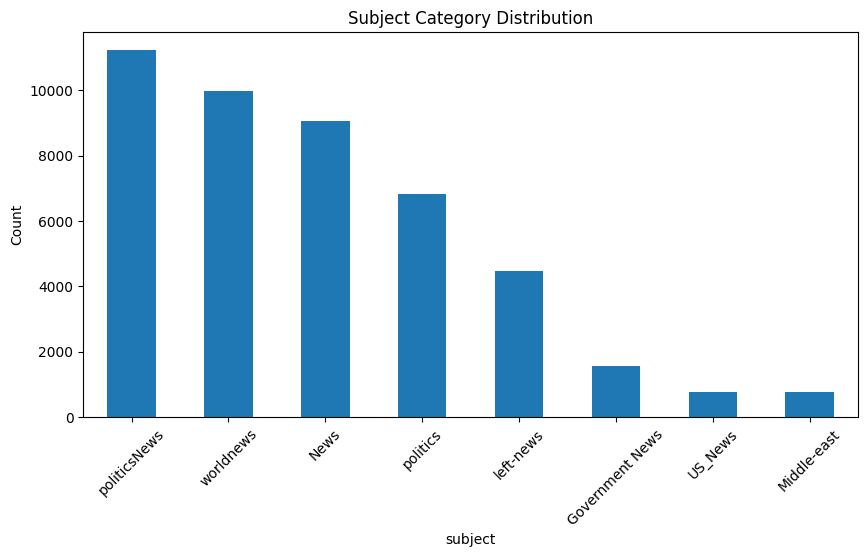

In [243]:
# ==========================================================
# SUBJECT CATEGORY ANALYSIS
# ==========================================================

plt.figure(figsize=(10,5))

df["subject"].value_counts().plot(
    kind='bar'
)

plt.title("Subject Category Distribution")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

#=====================================================================
#Observation : Politics is the most dominant subject category in the dataset, indicating that political news is more frequently represented than other topics. This suggests that political content plays a significant role in fake news detection.
#=====================================================================

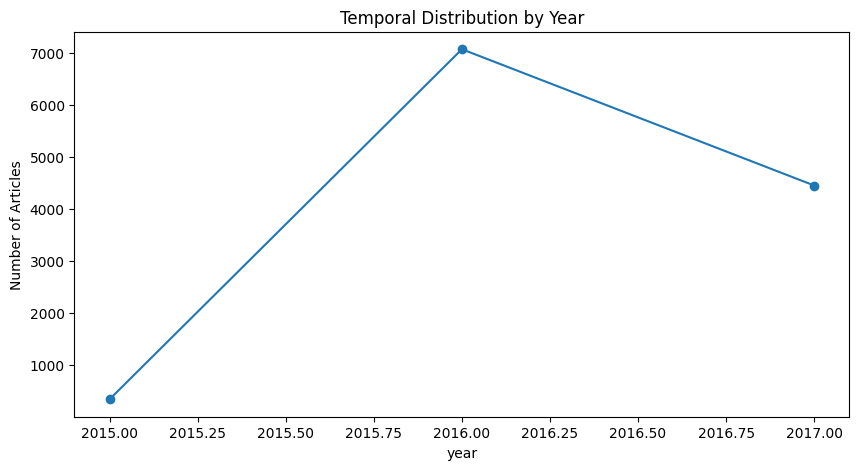

In [244]:
# ============================================================
# DATE PROCESSING
# ============================================================

df["date"] = pd.to_datetime(
    df["date"],
    errors="coerce"
)

df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month


# ==========================================================
# DATE ANALYSIS
# ==========================================================

df["date"] = pd.to_datetime(
    df["date"],
    errors="coerce"
)

df["year"] = df["date"].dt.year

plt.figure(figsize=(10,5))

df["year"].value_counts().sort_index().plot(
    kind='line',
    marker='o'
)

plt.title("Temporal Distribution by Year")
plt.ylabel("Number of Articles")
plt.show()


Average Title Length:
label
0    94.194054
1    64.658291
Name: title_char_count, dtype: float64


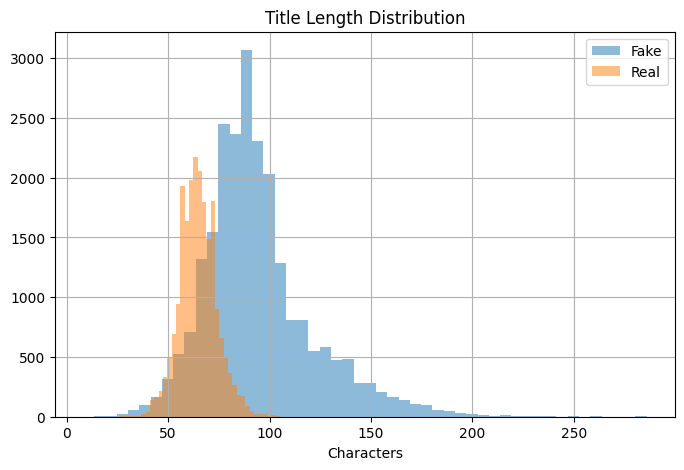


Average Title Length
label
0    94.194054
1    64.658291
Name: title_char_count, dtype: float64


In [245]:
# ============================================================
# TITLE LENGTH FEATURES
# ============================================================

df["title_char_count"] = df["title"].astype(str).apply(len)

df["title_word_count"] = df["title"].astype(str).apply(
    lambda x: len(x.split())
)

print("\nAverage Title Length:")
print(
    df.groupby("label")["title_char_count"].mean()
)

plt.figure(figsize=(8,5))

for label,name in zip([0,1],["Fake","Real"]):

    df[df["label"]==label]["title_char_count"].hist(
        bins=50,
        alpha=0.5,
        label=name
    )

plt.legend()
plt.title("Title Length Distribution")
plt.xlabel("Characters")
plt.show()

print("\nAverage Title Length")
print(df.groupby("label")["title_char_count"].mean())


Average Word Count:
label
0    423.224167
1    384.757484
Name: word_count, dtype: float64


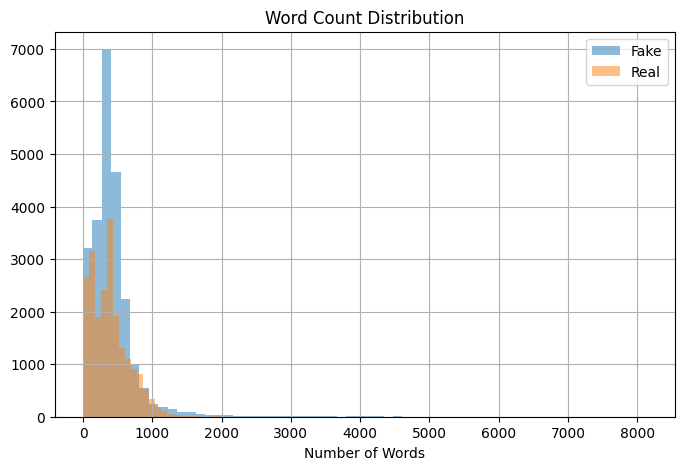

In [246]:
# ============================================================
# TEXT LENGTH FEATURES
# ============================================================

df["text_char_count"] = df["text"].astype(str).apply(len)

df["word_count"] = df["text"].astype(str).apply(
    lambda x: len(x.split())
)

print("\nAverage Word Count:")
print(
    df.groupby("label")["word_count"].mean()
)

plt.figure(figsize=(8,5))

for label,name in zip([0,1],["Fake","Real"]):

    df[df["label"]==label]["word_count"].hist(
        bins=60,
        alpha=0.5,
        label=name
    )

plt.legend()
plt.title("Word Count Distribution")
plt.xlabel("Number of Words")
plt.show()

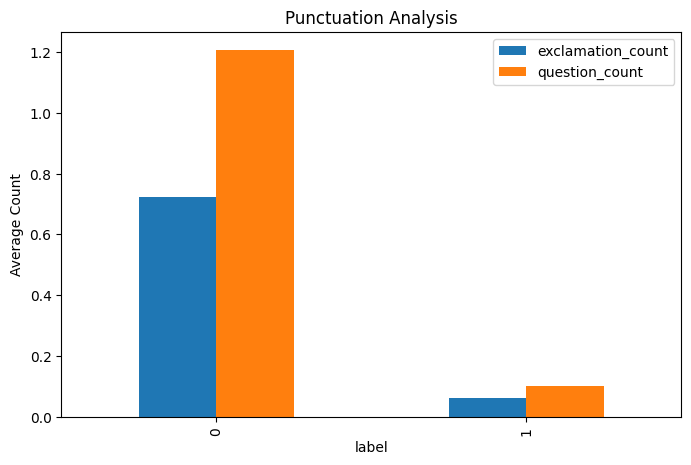


Punctuation Analysis
       exclamation_count  question_count
label                                   
0               0.722847        1.205682
1               0.062090        0.100325


In [247]:
# ==========================================================
# PUNCTUATION ANALYSIS
# ==========================================================

df["exclamation_count"] = df["text"].astype(str).apply(
    lambda x: x.count("!")
)

df["question_count"] = df["text"].astype(str).apply(
    lambda x: x.count("?")
)

punctuation = df.groupby("label")[
    ["exclamation_count","question_count"]
].mean()

punctuation.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title("Punctuation Analysis")
plt.ylabel("Average Count")
plt.show()

print("\nPunctuation Analysis")
print(punctuation)


In [248]:
# ============================================================
# UPPERCASE RATIO
# ============================================================

def uppercase_ratio(text):

    text = str(text)

    total = len(text)

    if total == 0:
        return 0

    upper = sum(1 for c in text if c.isupper())

    return upper / total

df["uppercase_ratio"] = df["text"].apply(
    uppercase_ratio
)

print("\nUppercase Ratio:")
print(
    df.groupby("label")["uppercase_ratio"].mean()
)


Uppercase Ratio:
label
0    0.045503
1    0.041783
Name: uppercase_ratio, dtype: float64


label               0      1
subject                     
Government News  1570      0
Middle-east       778      0
News             9050      0
US_News           783      0
left-news        4459      0
politics         6838      0
politicsNews        0  11220
worldnews           0   9991


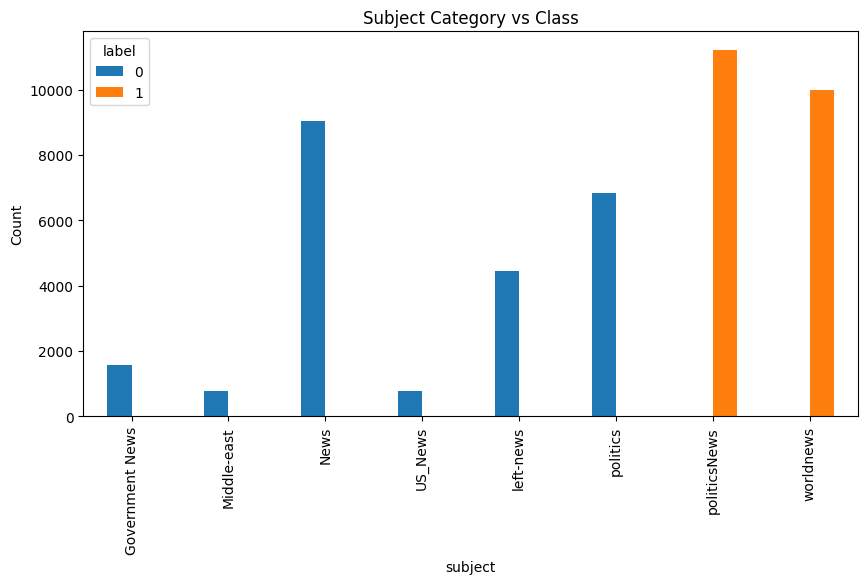

In [249]:
# ============================================================
# SUBJECT VS CLASS
# ============================================================

subject_class = pd.crosstab(
    df["subject"],
    df["label"]
)

print(subject_class)

subject_class.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Subject Category vs Class")
plt.ylabel("Count")
plt.show()

In [250]:
# ============================================================
# TOP WORDS ANALYSIS
# ============================================================

stop_words = set(stopwords.words("english"))

def get_top_words(text_series, n=20):

    words = []

    for text in text_series:

        tokens = str(text).lower().split()

        tokens = [
            word.strip(".,!?;:\"'()[]{}")
            for word in tokens
        ]

        tokens = [
            word for word in tokens
            if word.isalpha()
            and word not in stop_words
        ]

        words.extend(tokens)

    return Counter(words).most_common(n)

fake_words = get_top_words(
    df[df["label"]==0]["text"]
)

real_words = get_top_words(
    df[df["label"]==1]["text"]
)

print("\nTop 20 Fake News Words")
print(fake_words)

print("\nTop 20 Real News Words")
print(real_words)


Top 20 Fake News Words
[('trump', 73290), ('said', 31005), ('people', 25937), ('president', 25463), ('would', 23419), ('one', 22858), ('clinton', 17945), ('obama', 17746), ('like', 17593), ('donald', 17098), ('also', 15221), ('new', 14135), ('news', 14087), ('us', 13781), ('even', 13655), ('hillary', 13494), ('white', 12762), ('time', 12664), ('state', 12494), ('via', 11140)]

Top 20 Real News Words
[('said', 97822), ('trump', 41580), ('would', 31062), ('reuters', 28010), ('president', 24949), ('state', 18347), ('government', 17578), ('new', 16554), ('house', 16146), ('states', 15832), ('also', 15735), ('united', 15345), ('republican', 15185), ('people', 14413), ('told', 14070), ('could', 13475), ('last', 12438), ('one', 12154), ('washington', 11997), ('two', 11441)]


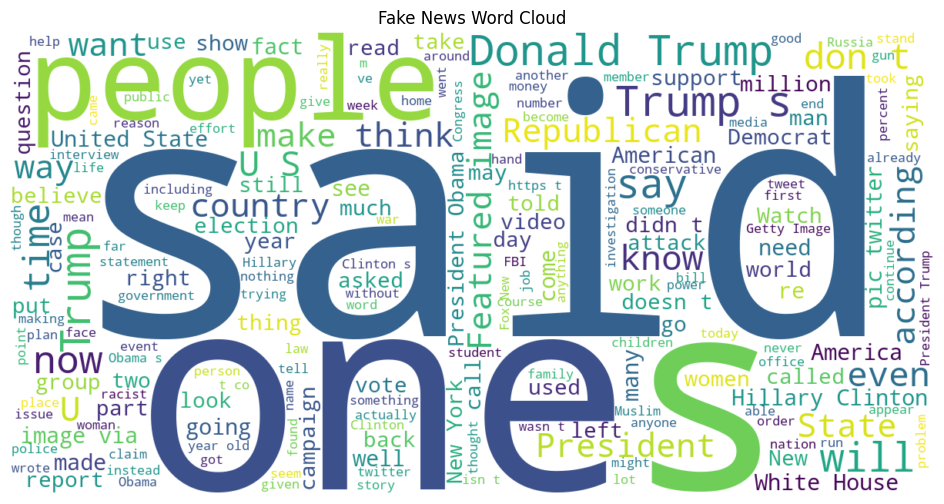

In [251]:
# ============================================================
# WORD CLOUD - FAKE NEWS
# ============================================================

fake_text = " ".join(
    df[df["label"]==0]["text"].astype(str)
)

wc_fake = WordCloud(
    width=1200,
    height=600,
    background_color="white"
).generate(fake_text)

plt.figure(figsize=(12,6))
plt.imshow(wc_fake, interpolation="bilinear")
plt.axis("off")
plt.title("Fake News Word Cloud")
plt.show()

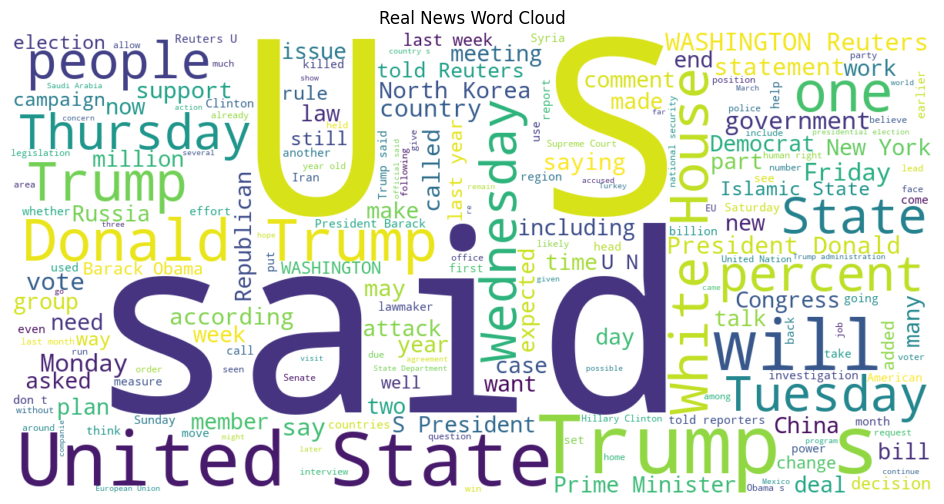

In [252]:
# ============================================================
# WORD CLOUD - REAL NEWS
# ============================================================

real_text = " ".join(
    df[df["label"]==1]["text"].astype(str)
)

wc_real = WordCloud(
    width=1200,
    height=600,
    background_color="white"
).generate(real_text)

plt.figure(figsize=(12,6))
plt.imshow(wc_real, interpolation="bilinear")
plt.axis("off")
plt.title("Real News Word Cloud")
plt.show()

In [253]:
# ============================================================
# SUMMARY STATISTICS
# ============================================================

eda_summary = df.groupby("label")[

    [
        "title_char_count",
        "title_word_count",
        "text_char_count",
        "word_count",
        "exclamation_count",
        "question_count",
        "uppercase_ratio"
    ]

].mean()

print("\nEDA SUMMARY")
print(eda_summary)

print("\nEDA COMPLETED SUCCESSFULLY")


EDA SUMMARY
       title_char_count  title_word_count  text_char_count  word_count  \
label                                                                    
0             94.194054         14.732388      2547.555882  423.224167   
1             64.658291          9.951582      2378.042337  384.757484   

       exclamation_count  question_count  uppercase_ratio  
label                                                      
0               0.722847        1.205682         0.045503  
1               0.062090        0.100325         0.041783  

EDA COMPLETED SUCCESSFULLY


In [254]:
import re

In [255]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [256]:
# ============================================================
# COMBINE TITLE + TEXT
# EDA showed title length/style differs strongly by class
# (avg 94 chars for Fake vs 65 chars for Real), so title is
# kept as part of the model input along with the body text
# ============================================================

df["content"] = df["title"].astype(str) + " " + df["text"].astype(str)

# ============================================================
# TEXT CLEANING
# ============================================================

def clean_text(text):

    text = text.lower()
    text = re.sub(r"http\S+|www\S+", " ", text)   # remove URLs
    text = re.sub(r"[^a-z\s]", " ", text)          # remove digits/punctuation
    text = re.sub(r"\s+", " ", text).strip()       # remove extra whitespace

    return text

df["clean_content"] = df["content"].apply(clean_text)

In [257]:
# ============================================================
# TRAIN-TEST SPLIT (80/20, STRATIFIED)
# ============================================================

X = df["clean_content"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples :", X_test.shape[0])

Training samples: 35751
Testing samples : 8938


In [ ]:
# ============================================================
# TF-IDF VECTORIZATION
# ============================================================

tfidf = TfidfVectorizer(
    max_features=5000,
    stop_words="english"
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("TF-IDF feature matrix shape:", X_train_tfidf.shape)

In [ ]:
# ============================================================
# MODEL TRAINING - LOGISTIC REGRESSION (BASELINE MODEL)
# ============================================================

model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

model.fit(X_train_tfidf, y_train)

# ============================================================
# PREDICTIONS
# ============================================================

y_train_pred = model.predict(X_train_tfidf)
y_test_pred = model.predict(X_test_tfidf)

In [ ]:
# ============================================================
# TRAIN VS TEST ACCURACY (OVERFITTING / UNDERFITTING CHECK)
# ============================================================

train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)

print("\nTraining Accuracy:", round(train_acc, 4))
print("Testing Accuracy :", round(test_acc, 4))
print("Accuracy Gap     :", round(train_acc - test_acc, 4))


In [ ]:
# ============================================================
# 5-FOLD CROSS VALIDATION
# ============================================================

cv_scores = cross_val_score(
    model,
    X_train_tfidf,
    y_train,
    cv=5,
    scoring="accuracy"
)

print("\n5-Fold CV Accuracy Scores:", np.round(cv_scores, 4))
print("Mean CV Accuracy:", round(cv_scores.mean(), 4))
print("CV Std Deviation:", round(cv_scores.std(), 4))

In [ ]:
# ============================================================
# CLASSIFICATION REPORT
# ============================================================

print("\nClassification Report (Test Set):")
print(classification_report(
    y_test, y_test_pred, target_names=["Fake", "Real"]
))

In [ ]:
# ============================================================
# FIGURE 11: CONFUSION MATRIX - LOGISTIC REGRESSION
# ============================================================

cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(7,5.5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Fake","Real"],
    yticklabels=["Fake","Real"],
    annot_kws={"size":13}
)

plt.title("Figure 11: Confusion Matrix - Logistic Regression (Baseline Model)", fontsize=12, pad=12)
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.tight_layout()
plt.show()